# Skin Cancer Classification & Age Regression using VGG and ResNet with Grad-CAM
**Dataset:** HAM10000 — Skin Cancer MNIST  
**Tasks:** Multi-class Classification (7 lesion types) + Regression (patient age)  
**Backbones:** VGG16, ResNet50  
**Interpretability:** Grad-CAM  

---

## 0. Install & Import Dependencies

In [1]:
# Install / upgrade necessary packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q grad-cam matplotlib seaborn scikit-learn pandas numpy Pillow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 17.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import vgg16, VGG16_Weights, resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import LabelEncoder

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4


## 1. Dataset Loading & Exploration

In [3]:
# ── Kaggle path configuration ──────────────────────────────────────────────
BASE_DIR = Path('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000')

# Locate all image folders
IMAGE_DIRS = [
    BASE_DIR / 'HAM10000_images_part_1',
    BASE_DIR / 'HAM10000_images_part_2',
]

META_CSV = BASE_DIR / 'HAM10000_metadata.csv'

# Build a quick image-id → path lookup
img_path_map: dict[str, Path] = {}
for d in IMAGE_DIRS:
    for p in d.glob('*.jpg'):
        img_path_map[p.stem] = p

print(f'Total images found : {len(img_path_map):,}')

df = pd.read_csv(META_CSV)
print(f'Metadata rows      : {len(df):,}')
df.head()

Total images found : 10,015
Metadata rows      : 10,015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
# ── Data cleaning ──────────────────────────────────────────────────────────
df['path'] = df['image_id'].map(img_path_map)
df.dropna(subset=['path', 'age'], inplace=True)
df['age'] = df['age'].astype(float)

# Encode target labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print(f'Samples after cleaning : {len(df):,}')
print(f'Classes ({NUM_CLASSES})          : {CLASS_NAMES}')
print(f'Age range              : {df["age"].min():.0f} – {df["age"].max():.0f}')

df[['dx', 'label']].value_counts().reset_index(name='count')

Samples after cleaning : 9,958
Classes (7)          : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Age range              : 0 – 85


,dx,label,count
0,nv,5,6660
1,mel,4,1111
2,bkl,2,1089
3,bcc,1,514
4,akiec,0,327
5,vasc,6,142
6,df,3,115


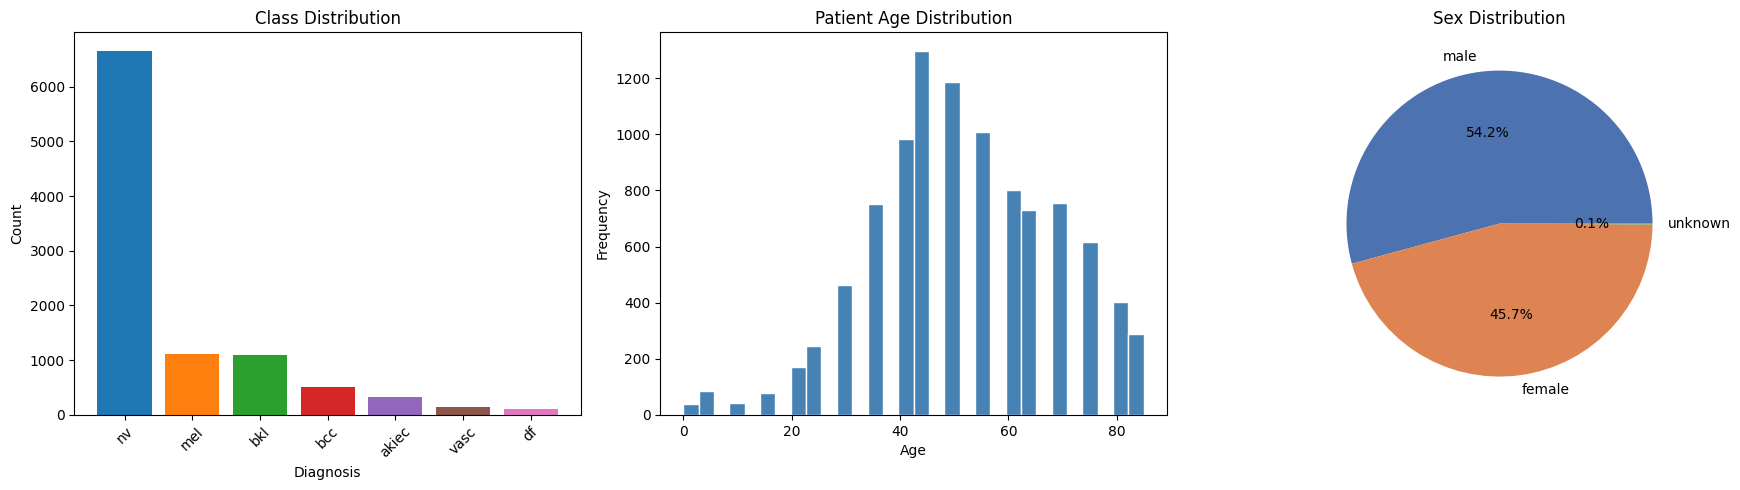

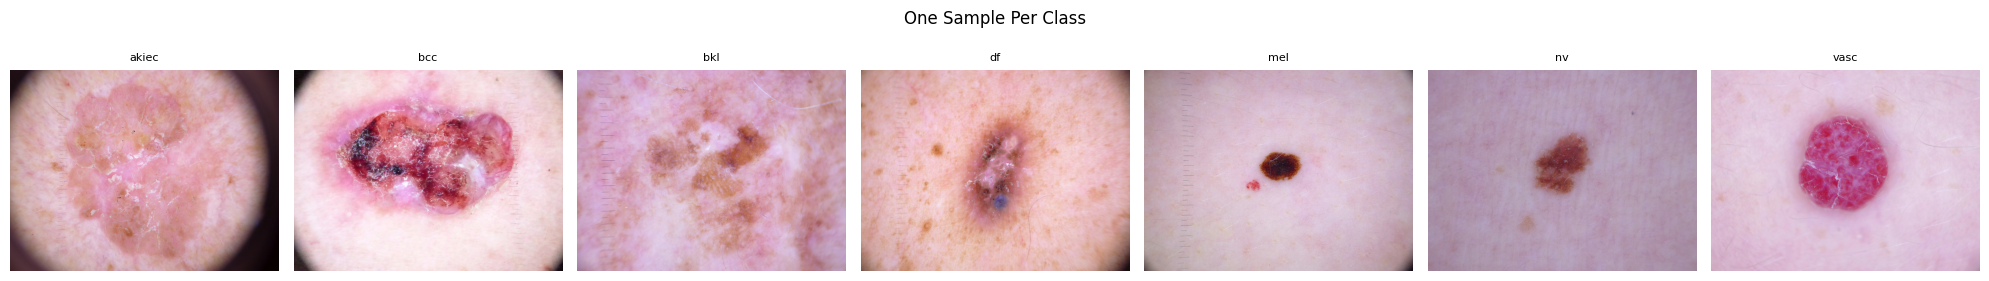

In [5]:
# ── EDA Visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
counts = df['dx'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('tab10', NUM_CLASSES))
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
axes[1].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Patient Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

# Sex distribution
sex_counts = df['sex'].value_counts()
axes[2].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A868'])
axes[2].set_title('Sex Distribution')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 3))
for i, cls in enumerate(CLASS_NAMES):
    row = df[df['dx'] == cls].iloc[0]
    img = Image.open(row['path'])
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=8)
    axes[i].axis('off')
plt.suptitle('One Sample Per Class')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Dataset & DataLoader

In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Transforms ────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class HAM10000Dataset(Dataset):
    """Returns (image_tensor, class_label, normalised_age)."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        # Normalise age to [0, 1] using training-set stats (fitted externally)
        self.ages = self.df['age'].values.astype(np.float32)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.long)
        age   = torch.tensor(self.ages[idx], dtype=torch.float32)
        return img, label, age


# ── Train / Val / Test split ───────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

# Normalise age on training statistics
AGE_MEAN = train_df['age'].mean()
AGE_STD  = train_df['age'].std()

for d in [train_df, val_df, test_df]:
    d['age'] = (d['age'] - AGE_MEAN) / AGE_STD

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# ── Weighted sampler to handle class imbalance ────────────────────────────
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_df['label'].values]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_ds = HAM10000Dataset(train_df, transform=train_transforms)
val_ds   = HAM10000Dataset(val_df,   transform=val_transforms)
test_ds  = HAM10000Dataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print('DataLoaders ready.')

Train: 7,966 | Val: 996 | Test: 996
DataLoaders ready.


## 3. Model Definitions

In [7]:
# ── VGG-16 ────────────────────────────────────────────────────────────────
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        weights = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
        base = vgg16(weights=weights)
        self.features = base.features
        self.avgpool  = base.avgpool
        # Replace classifier head
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class VGG16Regressor(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
        base = vgg16(weights=weights)
        self.features = base.features
        self.avgpool  = base.avgpool
        self.regressor = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1),  # scalar output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.regressor(x).squeeze(1)


# ── ResNet-50 ─────────────────────────────────────────────────────────────
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = resnet50(weights=weights)
        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )
        self.model = base

    def forward(self, x):
        return self.model(x)


class ResNet50Regressor(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = resnet50(weights=weights)
        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 1),
        )
        self.model = base

    def forward(self, x):
        return self.model(x).squeeze(1)


# Quick sanity check
dummy = torch.zeros(2, 3, 224, 224)
for Model, args in [
    (VGG16Classifier,   (NUM_CLASSES,)),
    (VGG16Regressor,    ()),
    (ResNet50Classifier,(NUM_CLASSES,)),
    (ResNet50Regressor, ()),
]:
    m = Model(*args)
    out = m(dummy)
    print(f'{Model.__name__}: output shape {out.shape}')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 234MB/s] 


VGG16Classifier: output shape torch.Size([2, 7])
VGG16Regressor: output shape torch.Size([2])
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


ResNet50Classifier: output shape torch.Size([2, 7])
ResNet50Regressor: output shape torch.Size([2])


## 4. Training Utilities

In [14]:
def train_epoch_cls(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in tqdm(loader, desc='  train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch_cls(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / total, correct / total, f1, all_preds, all_labels


def train_epoch_reg(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total = 0.0, 0
    for imgs, _, ages in tqdm(loader, desc='  train', leave=False):
        imgs, ages = imgs.to(device), ages.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, ages)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
    return total_loss / total


@torch.no_grad()
def eval_epoch_reg(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    all_preds, all_true = [], []
    for imgs, _, ages in loader:
        imgs, ages = imgs.to(device), ages.to(device)
        preds = model(imgs)
        loss  = criterion(preds, ages)
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(ages.cpu().numpy())
    # Denormalise for interpretable metrics
    preds_real = np.array(all_preds) * AGE_STD + AGE_MEAN
    true_real  = np.array(all_true)  * AGE_STD + AGE_MEAN
    rmse = np.sqrt(mean_squared_error(true_real, preds_real))
    mae  = mean_absolute_error(true_real, preds_real)
    r2   = r2_score(true_real, preds_real)
    return total_loss / total, rmse, mae, r2, preds_real, true_real


def plot_history(history: dict, title: str, save_path: str):
    # 1. Dynamically count unique metrics (e.g., 'loss', 'rmse')
    metrics = list(dict.fromkeys(k.replace('train_', '').replace('val_', '') for k in history))
    num_plots = len(metrics)
    
    # 2. Create the subplots
    fig, axes = plt.subplots(1, num_plots, figsize=(7 * num_plots, 4))
    
    # 3. FIX: If Matplotlib returns a single object, wrap it in a list so it's iterable
    if num_plots == 1:
        axes = [axes]
        
    for ax, metric in zip(axes, metrics):
        if f'train_{metric}' in history:
            if len(history[f'train_{metric}']) > 0:
                ax.plot(history[f'train_{metric}'], label='Train')
        if f'val_{metric}' in history:
            if len(history[f'val_{metric}']) > 0:
                ax.plot(history[f'val_{metric}'],   label='Val')
        
        ax.set_title(metric.upper())
        ax.set_xlabel('Epoch')
        ax.legend()
        
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 5a. Train — VGG16 Classification

Epoch 01/20 | Loss 0.7571/1.4229 | Acc 0.4498/0.1747 | F1 0.1063


Epoch 02/20 | Loss 0.4633/1.1984 | Acc 0.5714/0.1878 | F1 0.1209


Epoch 03/20 | Loss 0.3063/1.1505 | Acc 0.6612/0.3454 | F1 0.3695


Epoch 04/20 | Loss 0.2368/0.9837 | Acc 0.7099/0.4930 | F1 0.5356


Epoch 05/20 | Loss 0.2179/0.8910 | Acc 0.7209/0.5331 | F1 0.5680


...

Epoch 16/20 | Loss 0.0375/0.8224 | Acc 0.9060/0.6446 | F1 0.6754


Epoch 17/20 | Loss 0.0324/0.8736 | Acc 0.9120/0.6396 | F1 0.6702


Epoch 18/20 | Loss 0.0299/0.8291 | Acc 0.9140/0.6556 | F1 0.6849


Epoch 19/20 | Loss 0.0276/0.8086 | Acc 0.9194/0.6506 | F1 0.6797


Epoch 20/20 | Loss 0.0291/0.8283 | Acc 0.9239/0.6466 | F1 0.6766


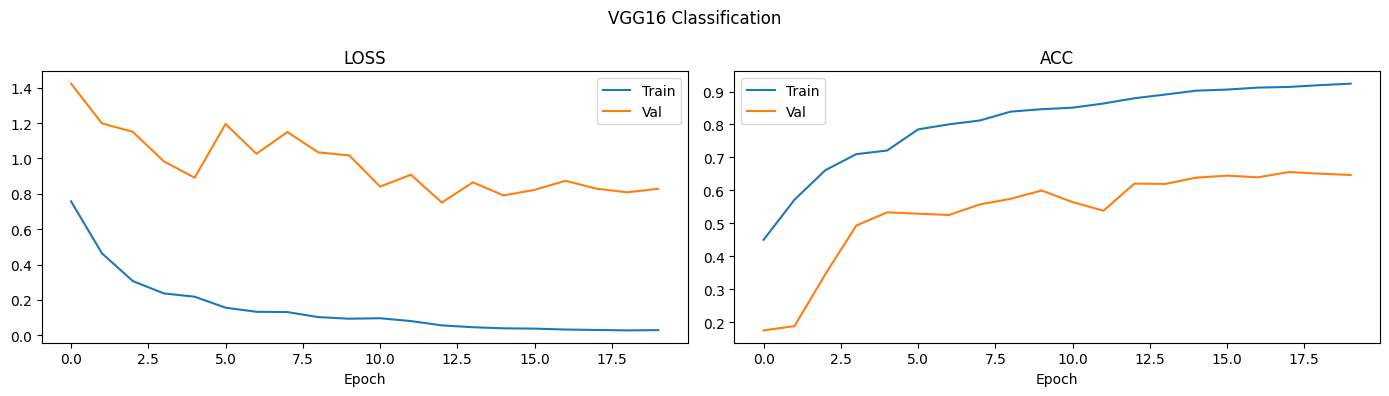


Best Val Acc: 0.6556


In [9]:
EPOCHS_CLS = 20
LR_CLS     = 1e-4

# Compute class weights for loss
cls_wts = torch.tensor(
    len(train_df) / (NUM_CLASSES * class_counts), dtype=torch.float32
).to(DEVICE)

vgg_cls = VGG16Classifier(NUM_CLASSES).to(DEVICE)
criterion_cls = nn.CrossEntropyLoss(weight=cls_wts)
optimizer_vgg_cls = optim.AdamW(vgg_cls.parameters(), lr=LR_CLS, weight_decay=1e-4)
scheduler_vgg_cls = optim.lr_scheduler.CosineAnnealingLR(optimizer_vgg_cls, T_max=EPOCHS_CLS)

hist_vgg_cls = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_vgg_cls_acc = 0.0

for epoch in range(1, EPOCHS_CLS + 1):
    tr_loss, tr_acc = train_epoch_cls(vgg_cls, train_loader, criterion_cls, optimizer_vgg_cls, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _ = eval_epoch_cls(vgg_cls, val_loader, criterion_cls, DEVICE)
    scheduler_vgg_cls.step()

    hist_vgg_cls['train_loss'].append(tr_loss)
    hist_vgg_cls['val_loss'].append(vl_loss)
    hist_vgg_cls['train_acc'].append(tr_acc)
    hist_vgg_cls['val_acc'].append(vl_acc)
    hist_vgg_cls['val_f1'].append(vl_f1)

    if vl_acc > best_vgg_cls_acc:
        best_vgg_cls_acc = vl_acc
        torch.save(vgg_cls.state_dict(), 'vgg16_classifier_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS_CLS} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.4f}/{vl_acc:.4f} | '
          f'F1 {vl_f1:.4f}')

plot_history(hist_vgg_cls, 'VGG16 Classification', 'vgg16_cls_history.png')
print(f'\nBest Val Acc: {best_vgg_cls_acc:.4f}')

## 5b. Train — VGG16 Regression

Epoch 01/20 | Loss 0.7867/0.8370 | RMSE 15.49 | MAE 12.20 | R² 0.1846


Epoch 02/20 | Loss 0.6410/1.0343 | RMSE 17.22 | MAE 13.61 | R² -0.0076


Epoch 03/20 | Loss 0.5358/0.6732 | RMSE 13.89 | MAE 10.87 | R² 0.3441


Epoch 04/20 | Loss 0.4576/0.6613 | RMSE 13.77 | MAE 10.83 | R² 0.3557


Epoch 05/20 | Loss 0.4267/0.7172 | RMSE 14.34 | MAE 11.27 | R² 0.3013


...

Epoch 16/20 | Loss 0.1502/0.5844 | RMSE 12.94 | MAE 10.00 | R² 0.4307


Epoch 17/20 | Loss 0.1398/0.5927 | RMSE 13.03 | MAE 10.06 | R² 0.4226


Epoch 18/20 | Loss 0.1372/0.5897 | RMSE 13.00 | MAE 10.03 | R² 0.4255


Epoch 19/20 | Loss 0.1339/0.5866 | RMSE 12.97 | MAE 10.01 | R² 0.4285


Epoch 20/20 | Loss 0.1279/0.5843 | RMSE 12.94 | MAE 9.99 | R² 0.4307


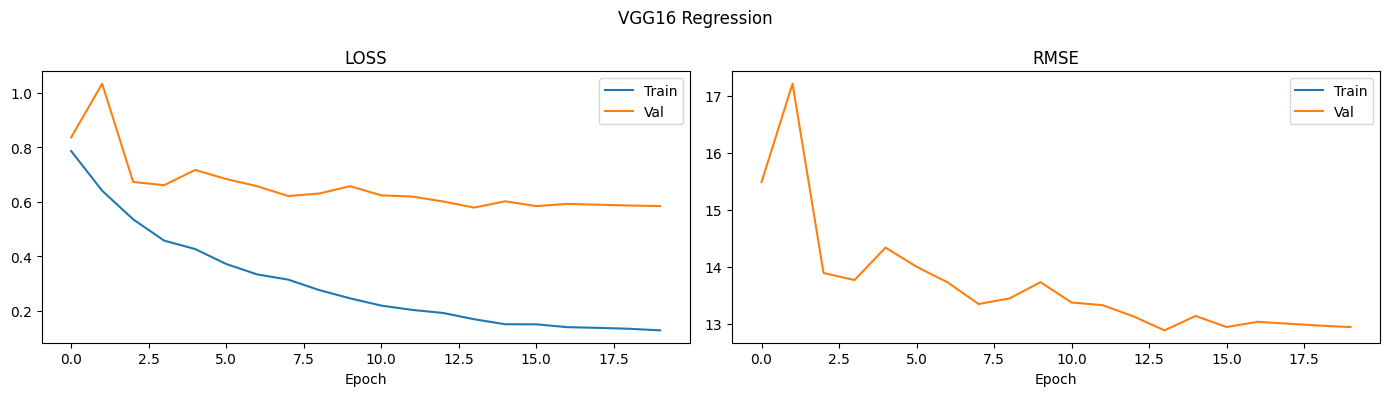


Best Val RMSE: 12.88


In [10]:
EPOCHS_REG = 20
LR_REG     = 1e-4

vgg_reg = VGG16Regressor().to(DEVICE)
criterion_reg     = nn.MSELoss()
optimizer_vgg_reg = optim.AdamW(vgg_reg.parameters(), lr=LR_REG, weight_decay=1e-4)
scheduler_vgg_reg = optim.lr_scheduler.CosineAnnealingLR(optimizer_vgg_reg, T_max=EPOCHS_REG)

hist_vgg_reg = {'train_loss': [], 'val_loss': [], 'train_rmse': [], 'val_rmse': []}
best_vgg_reg_rmse = float('inf')

for epoch in range(1, EPOCHS_REG + 1):
    tr_loss = train_epoch_reg(vgg_reg, train_loader, criterion_reg, optimizer_vgg_reg, DEVICE)
    vl_loss, vl_rmse, vl_mae, vl_r2, _, _ = eval_epoch_reg(vgg_reg, val_loader, criterion_reg, DEVICE)
    scheduler_vgg_reg.step()

    hist_vgg_reg['train_loss'].append(tr_loss)
    hist_vgg_reg['val_loss'].append(vl_loss)
    hist_vgg_reg['val_rmse'].append(vl_rmse)

    if vl_rmse < best_vgg_reg_rmse:
        best_vgg_reg_rmse = vl_rmse
        torch.save(vgg_reg.state_dict(), 'vgg16_regressor_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS_REG} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'RMSE {vl_rmse:.2f} | MAE {vl_mae:.2f} | R² {vl_r2:.4f}')

plot_history(hist_vgg_reg, 'VGG16 Regression', 'vgg16_reg_history.png')
print(f'\nBest Val RMSE: {best_vgg_reg_rmse:.2f}')

## 5c. Train — ResNet50 Classification

Epoch 01/20 | Loss 0.6336/1.2211 | Acc 0.4834/0.1968 | F1 0.1047


Epoch 02/20 | Loss 0.2105/1.0721 | Acc 0.7133/0.4116 | F1 0.4412


Epoch 03/20 | Loss 0.1676/0.8996 | Acc 0.7841/0.5351 | F1 0.5695


Epoch 04/20 | Loss 0.1225/0.8106 | Acc 0.8274/0.5803 | F1 0.6100


Epoch 05/20 | Loss 0.0934/0.7998 | Acc 0.8522/0.6114 | F1 0.6410


...

Epoch 16/20 | Loss 0.0176/0.6385 | Acc 0.9414/0.7410 | F1 0.7651


Epoch 17/20 | Loss 0.0167/0.6741 | Acc 0.9431/0.7219 | F1 0.7453


Epoch 18/20 | Loss 0.0160/0.6483 | Acc 0.9451/0.7249 | F1 0.7489


Epoch 19/20 | Loss 0.0144/0.6542 | Acc 0.9453/0.7169 | F1 0.7431


Epoch 20/20 | Loss 0.0132/0.6444 | Acc 0.9517/0.7209 | F1 0.7464


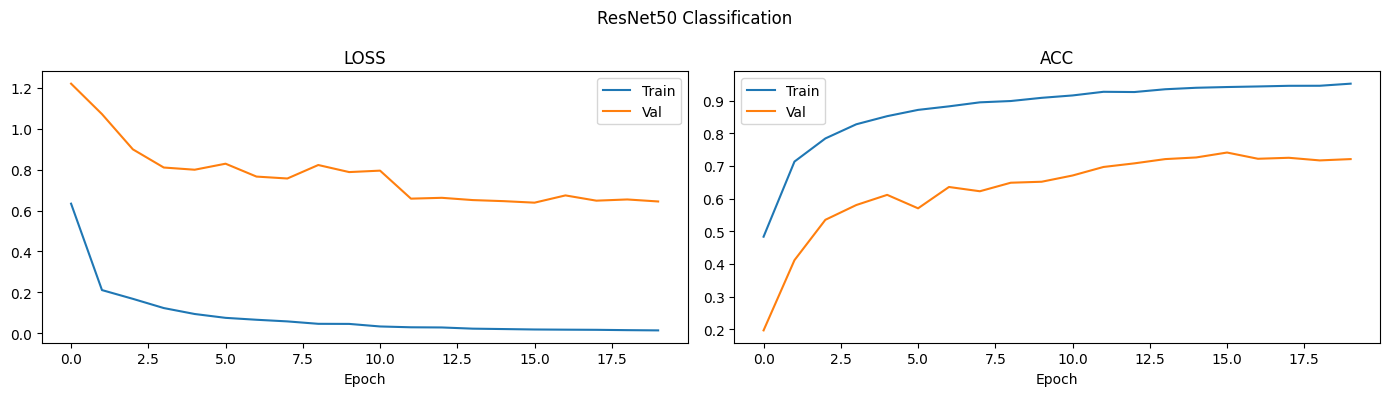


Best Val Acc: 0.7410


In [11]:
resnet_cls = ResNet50Classifier(NUM_CLASSES).to(DEVICE)
optimizer_res_cls = optim.AdamW(resnet_cls.parameters(), lr=LR_CLS, weight_decay=1e-4)
scheduler_res_cls = optim.lr_scheduler.CosineAnnealingLR(optimizer_res_cls, T_max=EPOCHS_CLS)

hist_res_cls = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_res_cls_acc = 0.0

for epoch in range(1, EPOCHS_CLS + 1):
    tr_loss, tr_acc = train_epoch_cls(resnet_cls, train_loader, criterion_cls, optimizer_res_cls, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _ = eval_epoch_cls(resnet_cls, val_loader, criterion_cls, DEVICE)
    scheduler_res_cls.step()

    hist_res_cls['train_loss'].append(tr_loss)
    hist_res_cls['val_loss'].append(vl_loss)
    hist_res_cls['train_acc'].append(tr_acc)
    hist_res_cls['val_acc'].append(vl_acc)
    hist_res_cls['val_f1'].append(vl_f1)

    if vl_acc > best_res_cls_acc:
        best_res_cls_acc = vl_acc
        torch.save(resnet_cls.state_dict(), 'resnet50_classifier_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS_CLS} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.4f}/{vl_acc:.4f} | '
          f'F1 {vl_f1:.4f}')

plot_history(hist_res_cls, 'ResNet50 Classification', 'resnet50_cls_history.png')
print(f'\nBest Val Acc: {best_res_cls_acc:.4f}')

## 5d. Train — ResNet50 Regression

Epoch 01/20 | Loss 0.6095/0.7851 | RMSE 15.00 | MAE 11.61 | R² 0.2351


Epoch 02/20 | Loss 0.4344/0.6540 | RMSE 13.69 | MAE 10.54 | R² 0.3629


Epoch 03/20 | Loss 0.3496/0.6029 | RMSE 13.14 | MAE 10.26 | R² 0.4127


Epoch 04/20 | Loss 0.2971/0.5571 | RMSE 12.64 | MAE 9.66 | R² 0.4573


Epoch 05/20 | Loss 0.2466/0.5556 | RMSE 12.62 | MAE 9.71 | R² 0.4587


...

Epoch 17/20 | Loss 0.0931/0.4581 | RMSE 11.46 | MAE 8.62 | R² 0.5537


Epoch 18/20 | Loss 0.0900/0.4480 | RMSE 11.33 | MAE 8.58 | R² 0.5636


Epoch 19/20 | Loss 0.0893/0.4465 | RMSE 11.31 | MAE 8.54 | R² 0.5650


Epoch 20/20 | Loss 0.0836/0.4482 | RMSE 11.33 | MAE 8.54 | R² 0.5633


TypeError: 'Axes' object is not iterable

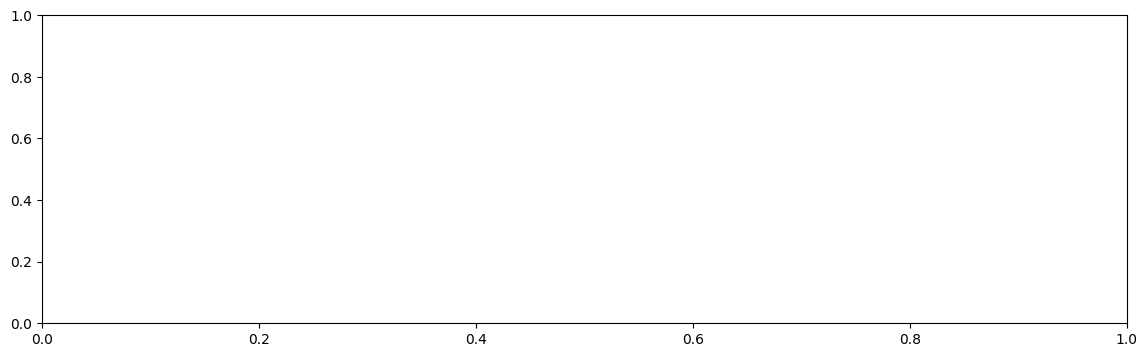

In [12]:
resnet_reg = ResNet50Regressor().to(DEVICE)
optimizer_res_reg = optim.AdamW(resnet_reg.parameters(), lr=LR_REG, weight_decay=1e-4)
scheduler_res_reg = optim.lr_scheduler.CosineAnnealingLR(optimizer_res_reg, T_max=EPOCHS_REG)

hist_res_reg = {'train_loss': [], 'val_loss': [], 'val_rmse': []}
best_res_reg_rmse = float('inf')

for epoch in range(1, EPOCHS_REG + 1):
    tr_loss = train_epoch_reg(resnet_reg, train_loader, criterion_reg, optimizer_res_reg, DEVICE)
    vl_loss, vl_rmse, vl_mae, vl_r2, _, _ = eval_epoch_reg(resnet_reg, val_loader, criterion_reg, DEVICE)
    scheduler_res_reg.step()

    hist_res_reg['train_loss'].append(tr_loss)
    hist_res_reg['val_loss'].append(vl_loss)
    hist_res_reg['val_rmse'].append(vl_rmse)

    if vl_rmse < best_res_reg_rmse:
        best_res_reg_rmse = vl_rmse
        torch.save(resnet_reg.state_dict(), 'resnet50_regressor_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS_REG} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'RMSE {vl_rmse:.2f} | MAE {vl_mae:.2f} | R² {vl_r2:.4f}')

plot_history(hist_res_reg, 'ResNet50 Regression', 'resnet50_reg_history.png')
print(f'\nBest Val RMSE: {best_res_reg_rmse:.2f}')

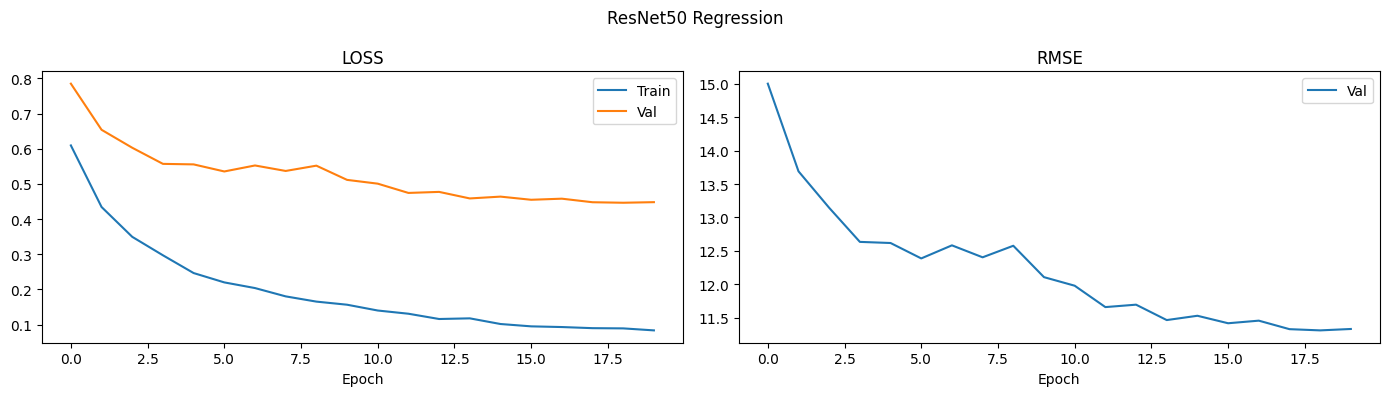


Best Val RMSE: 11.31


In [15]:
plot_history(hist_res_reg, 'ResNet50 Regression', 'resnet50_reg_history.png')
print(f'\nBest Val RMSE: {best_res_reg_rmse:.2f}')

## 6. Evaluation on Test Set


── VGG16 Classification ──
Accuracy : 0.6667
F1-Score : 0.6929
              precision    recall  f1-score   support

       akiec       0.68      0.76      0.71        33
         bcc       0.70      0.88      0.78        52
         bkl       0.52      0.85      0.65       109
          df       0.64      0.82      0.72        11
         mel       0.32      0.87      0.47       111
          nv       1.00      0.57      0.73       666
        vasc       0.74      1.00      0.85        14

    accuracy                           0.67       996
   macro avg       0.66      0.82      0.70       996
weighted avg       0.84      0.67      0.69       996



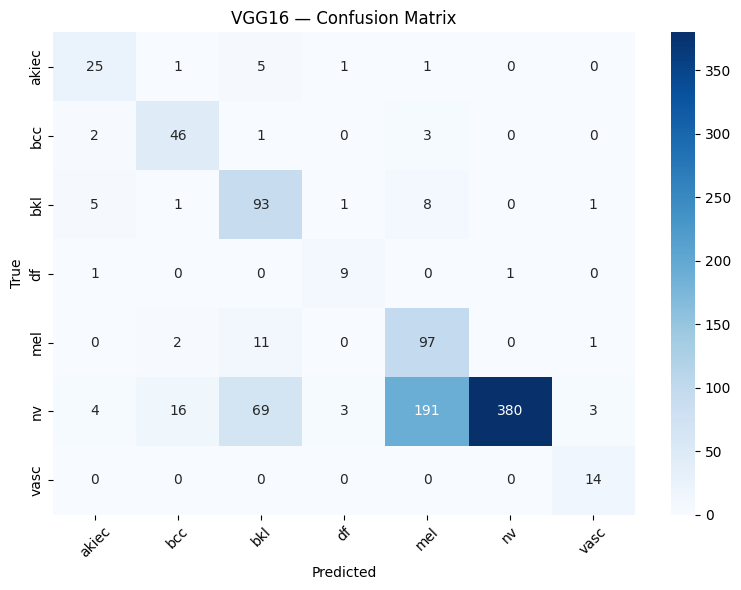


── ResNet50 Classification ──
Accuracy : 0.7490
F1-Score : 0.7692
              precision    recall  f1-score   support

       akiec       0.58      0.79      0.67        33
         bcc       0.64      0.94      0.76        52
         bkl       0.67      0.79      0.72       109
          df       0.77      0.91      0.83        11
         mel       0.40      0.86      0.55       111
          nv       0.99      0.70      0.82       666
        vasc       0.74      1.00      0.85        14

    accuracy                           0.75       996
   macro avg       0.68      0.86      0.74       996
weighted avg       0.85      0.75      0.77       996



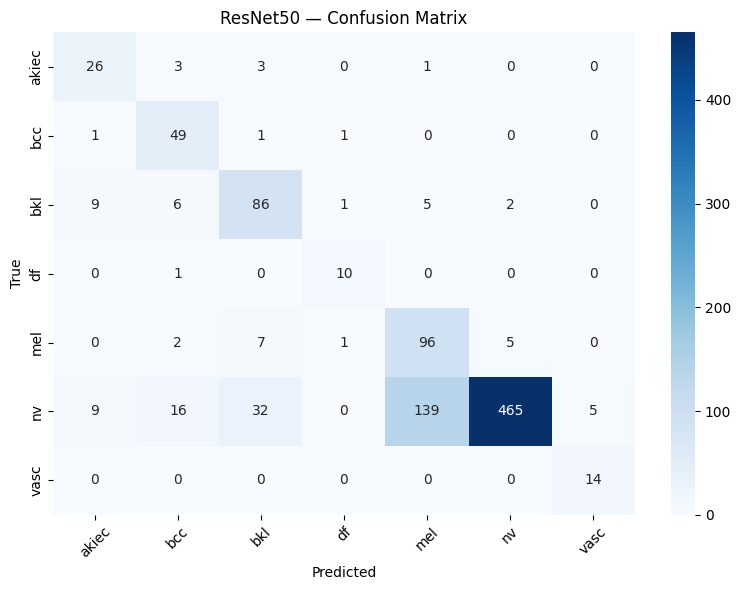


── VGG16 Regression ──
RMSE : 13.14 years
MAE  : 10.17  years
R²   : 0.4082


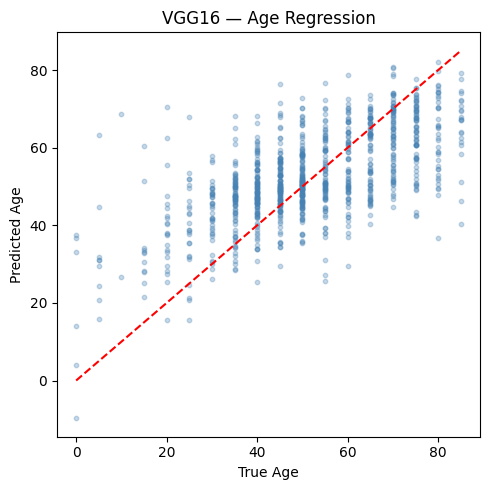


── ResNet50 Regression ──
RMSE : 11.69 years
MAE  : 9.09  years
R²   : 0.5318


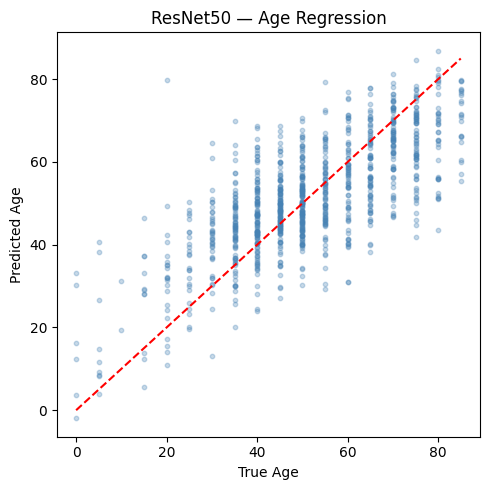

In [16]:
def load_best(model, path):
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE)
    return model

vgg_cls    = load_best(VGG16Classifier(NUM_CLASSES),   'vgg16_classifier_best.pth')
vgg_reg    = load_best(VGG16Regressor(),               'vgg16_regressor_best.pth')
resnet_cls = load_best(ResNet50Classifier(NUM_CLASSES),'resnet50_classifier_best.pth')
resnet_reg = load_best(ResNet50Regressor(),            'resnet50_regressor_best.pth')

# ── Classification metrics ────────────────────────────────────────────────
results = {}

for name, model in [('VGG16', vgg_cls), ('ResNet50', resnet_cls)]:
    _, acc, f1, preds, labels = eval_epoch_cls(model, test_loader, criterion_cls, DEVICE)
    results[f'{name}_cls'] = {
        'Accuracy': round(acc, 4),
        'F1-Score (weighted)': round(f1, 4),
    }
    print(f'\n── {name} Classification ──')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Regression metrics ────────────────────────────────────────────────────
for name, model in [('VGG16', vgg_reg), ('ResNet50', resnet_reg)]:
    _, rmse, mae, r2, preds_r, true_r = eval_epoch_reg(model, test_loader, criterion_reg, DEVICE)
    results[f'{name}_reg'] = {
        'RMSE (years)': round(rmse, 2),
        'MAE  (years)': round(mae,  2),
        'R²': round(r2, 4),
    }
    print(f'\n── {name} Regression ──')
    print(f'RMSE : {rmse:.2f} years')
    print(f'MAE  : {mae:.2f}  years')
    print(f'R²   : {r2:.4f}')

    plt.figure(figsize=(5, 5))
    plt.scatter(true_r, preds_r, alpha=0.3, s=10, color='steelblue')
    plt.plot([true_r.min(), true_r.max()], [true_r.min(), true_r.max()], 'r--')
    plt.xlabel('True Age')
    plt.ylabel('Predicted Age')
    plt.title(f'{name} — Age Regression')
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_regression_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Grad-CAM Visualisations

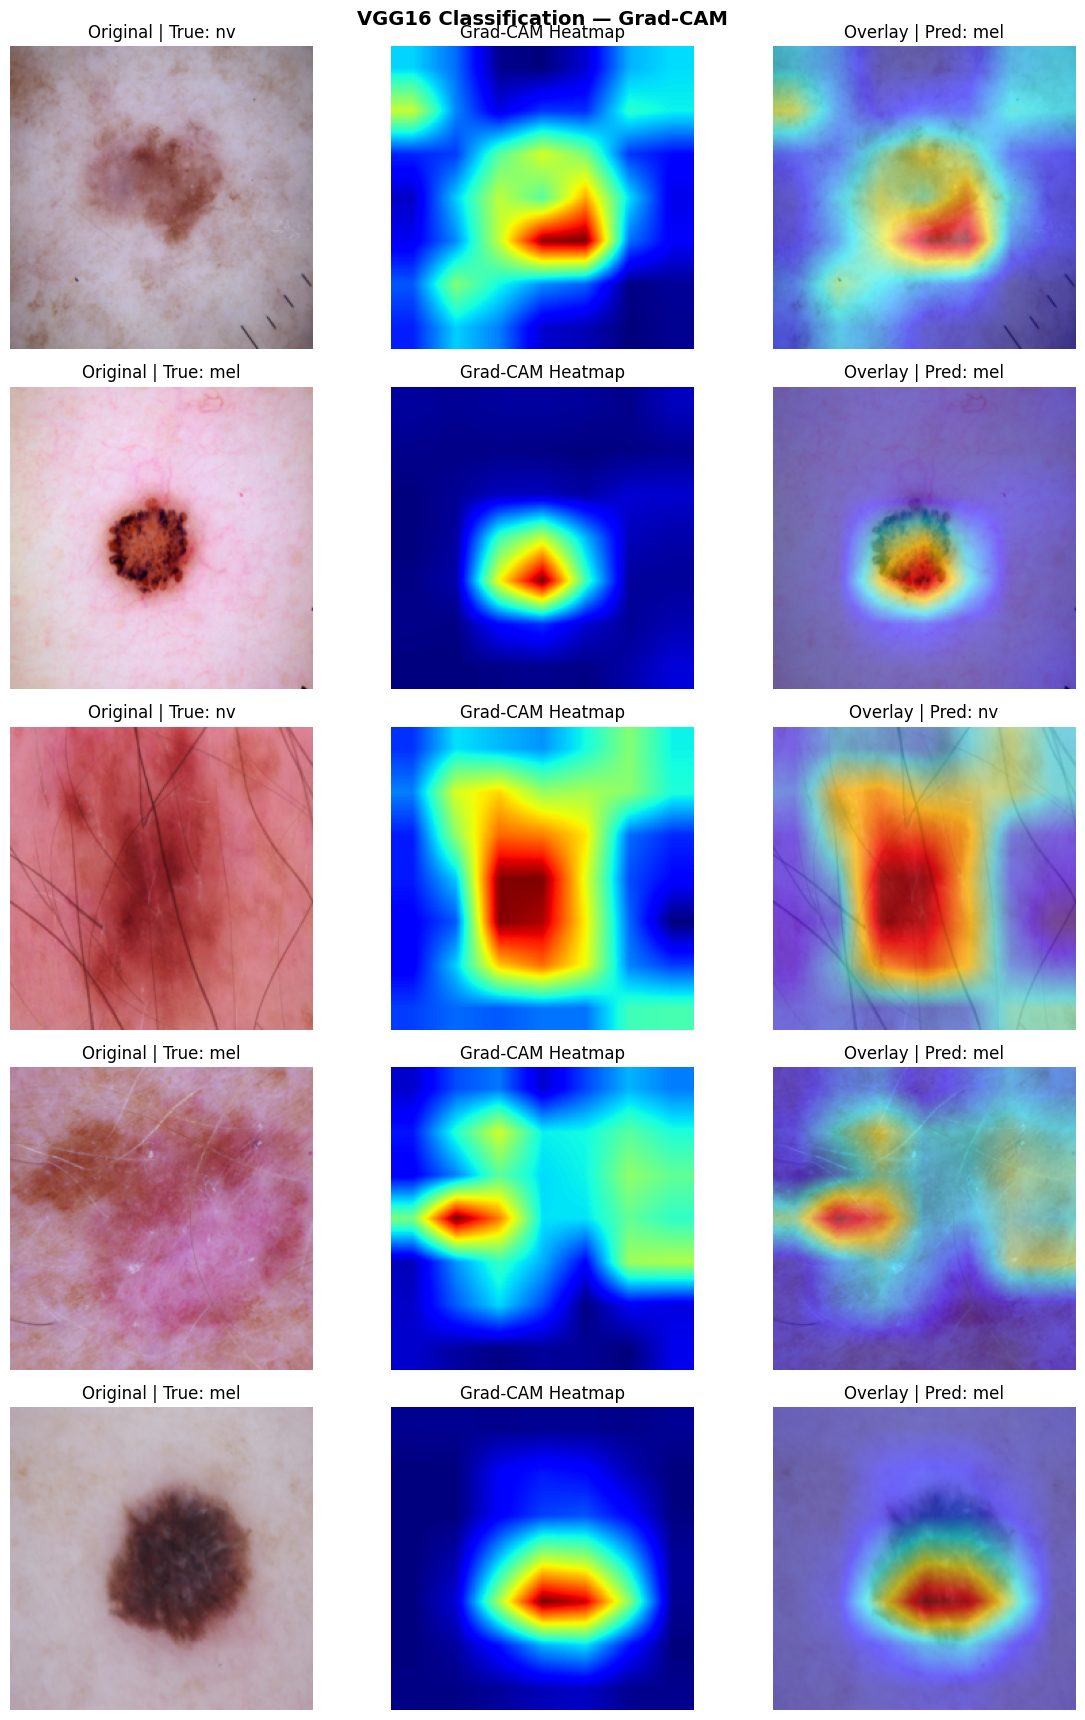

Saved → gradcam_vgg16_cls.png


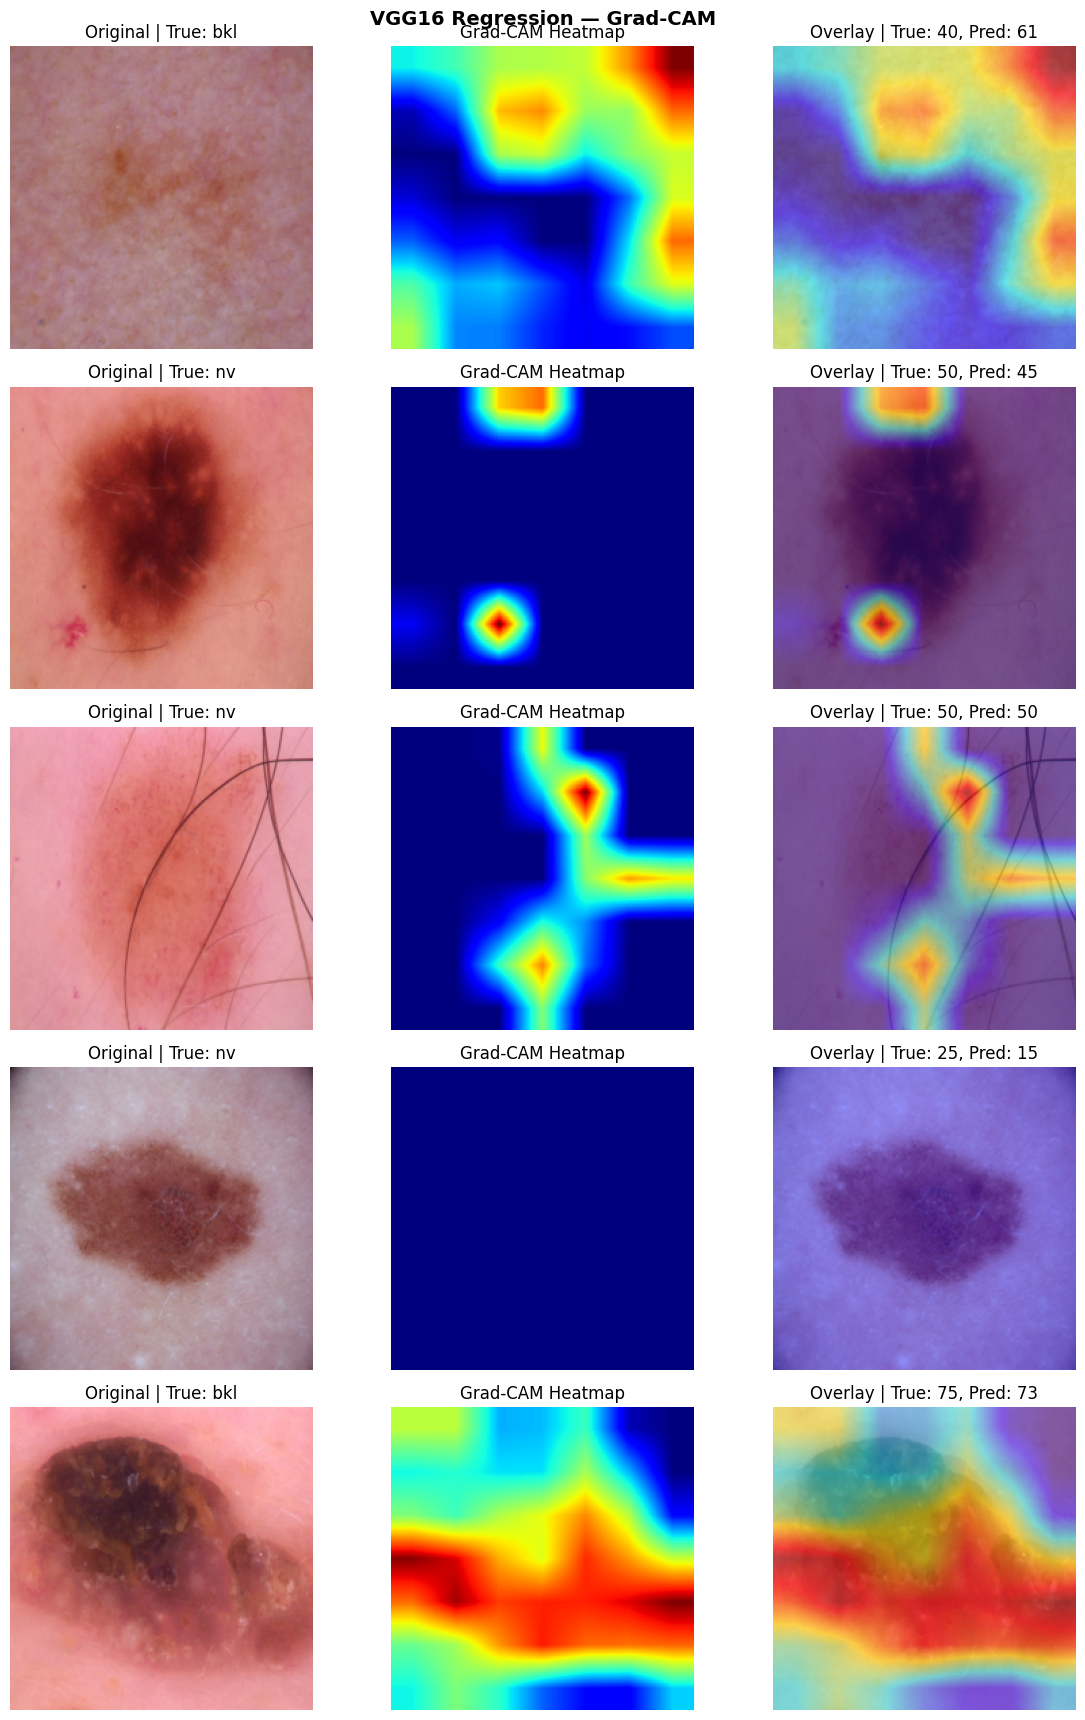

Saved → gradcam_vgg16_reg.png


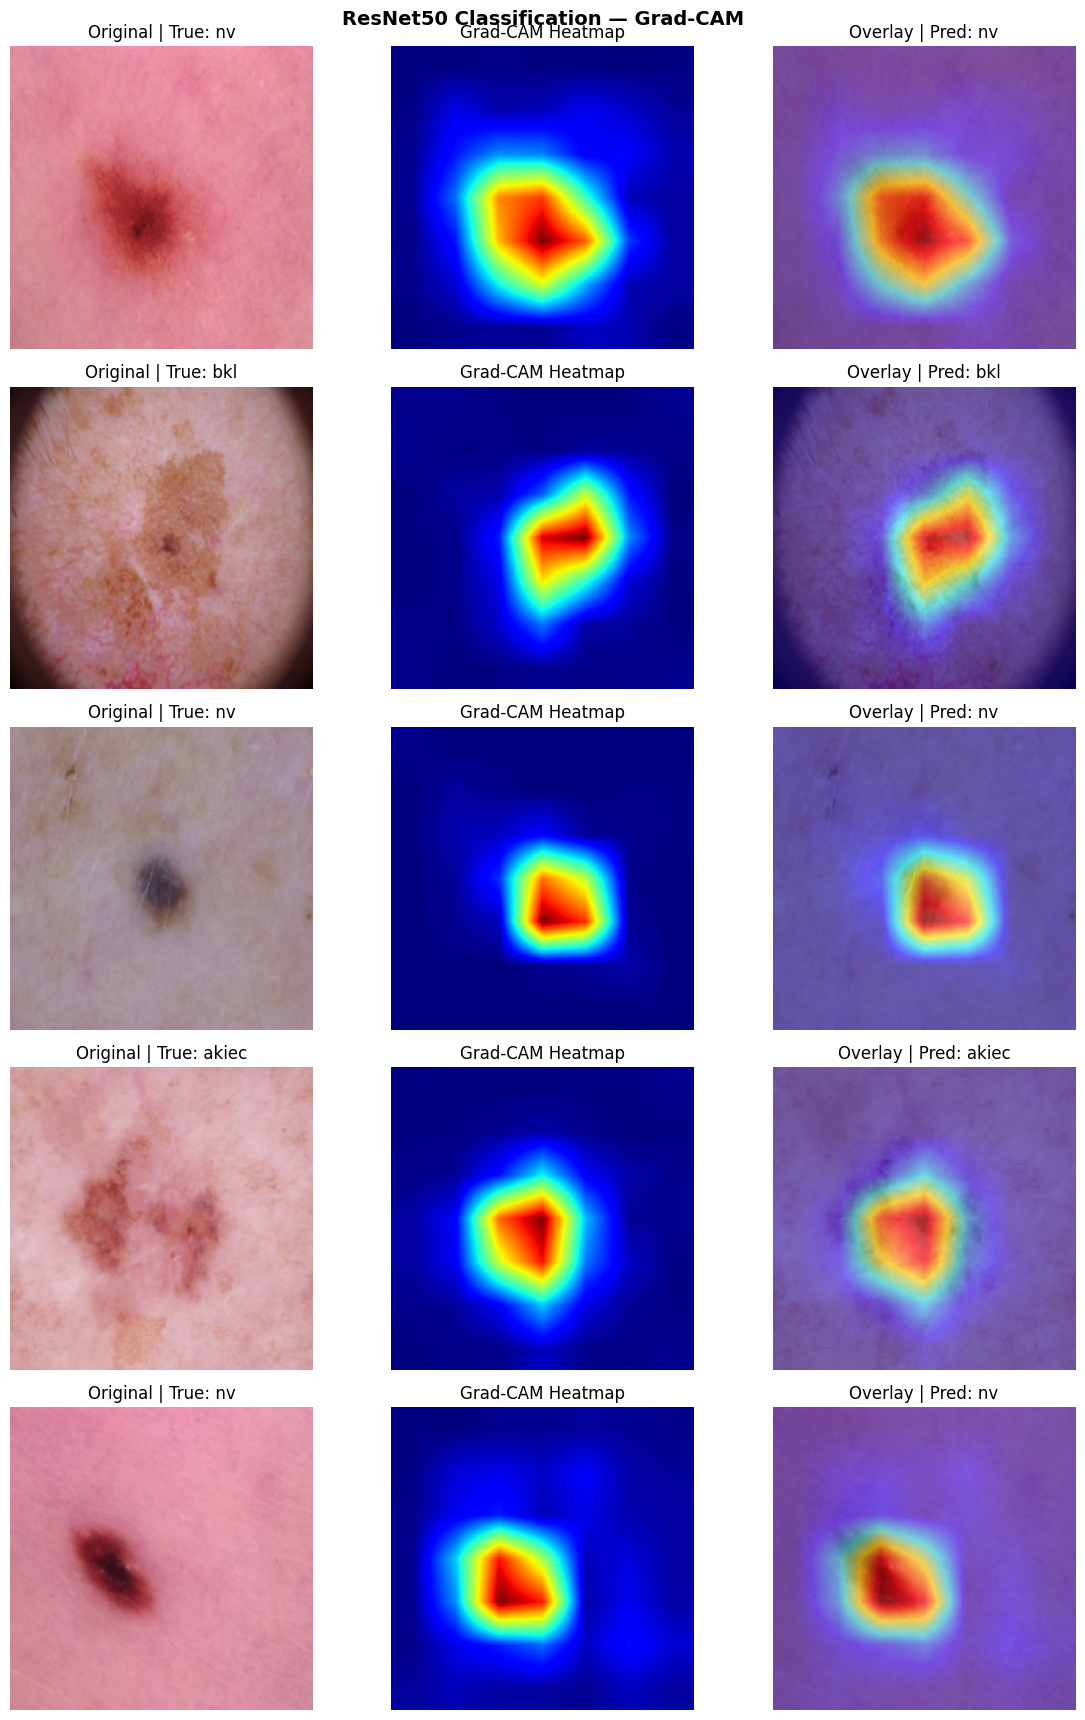

Saved → gradcam_resnet50_cls.png


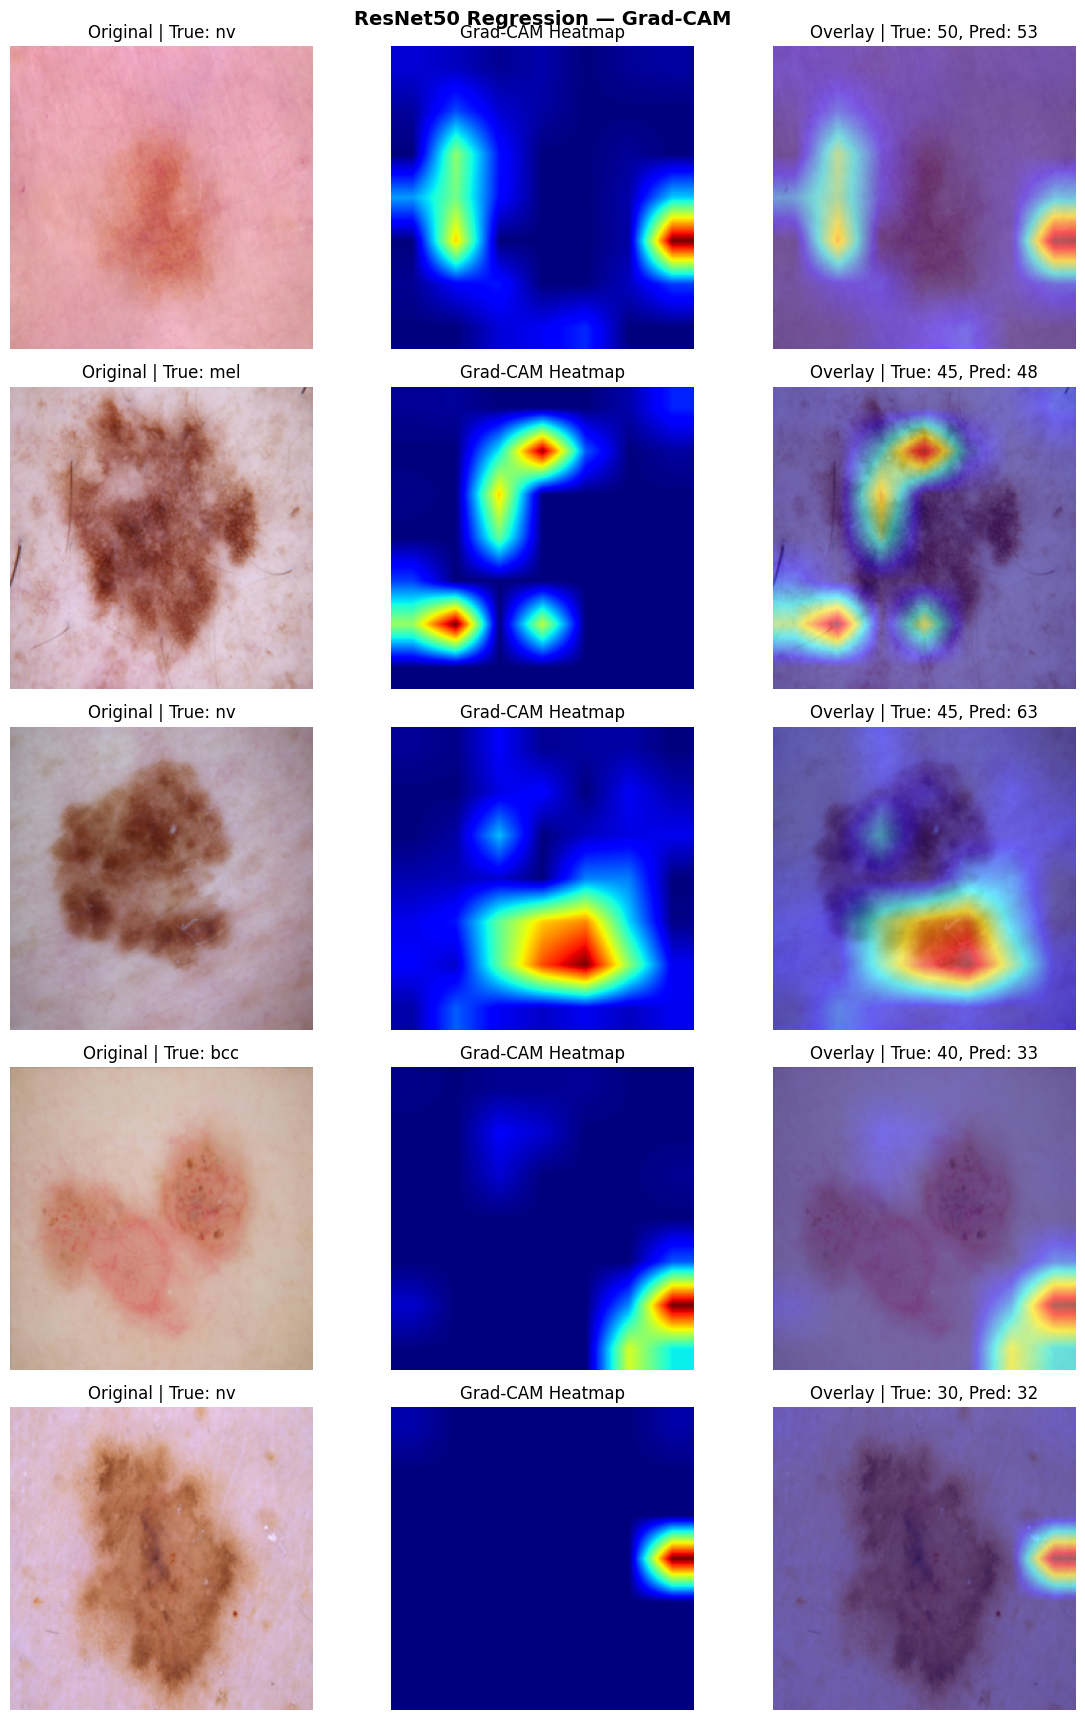

Saved → gradcam_resnet50_reg.png


In [19]:
class RegressionTarget:
    """Custom target for pytorch_grad_cam to handle continuous regression outputs."""
    def __call__(self, model_output):
        return model_output

def get_gradcam_target_layer(model):
    """Return the last convolutional layer for each architecture."""
    if isinstance(model, (VGG16Classifier, VGG16Regressor)):
        return [model.features[-1]]          # conv5_3
    elif isinstance(model, (ResNet50Classifier, ResNet50Regressor)):
        return [model.model.layer4[-1]]       # layer4 block 2
    raise ValueError('Unknown model type')


def visualise_gradcam(model, dataset, num_samples: int, title: str, save_name: str,
                      task: str = 'cls'):
    model.eval()
    target_layers = get_gradcam_target_layer(model)
    cam = GradCAM(model=model, target_layers=target_layers)

    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3.5))

    denorm = transforms.Compose([
        transforms.Normalize(mean=[0, 0, 0], std=[1/s for s in IMAGENET_STD]),
        transforms.Normalize(mean=[-m for m in IMAGENET_MEAN], std=[1, 1, 1]),
    ])

    for row_idx, ds_idx in enumerate(indices):
        img_tensor, label, age = dataset[ds_idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        # Predict
        with torch.no_grad():
            out = model(input_tensor)

        if task == 'cls':
            pred_cls = out.argmax(1).item()
            targets = [ClassifierOutputTarget(pred_cls)]
        else:
            # FIX: Use our custom RegressionTarget instead of None
            targets = [RegressionTarget()]  

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Convert tensor to displayable RGB
        rgb = denorm(img_tensor).permute(1, 2, 0).numpy()
        rgb = np.clip(rgb, 0, 1).astype(np.float32)

        cam_img = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

        ax = axes[row_idx] if num_samples > 1 else axes
        ax[0].imshow(rgb)
        ax[0].set_title(f'Original | True: {CLASS_NAMES[label.item()]}')
        ax[0].axis('off')

        ax[1].imshow(grayscale_cam, cmap='jet')
        ax[1].set_title('Grad-CAM Heatmap')
        ax[1].axis('off')

        ax[2].imshow(cam_img)
        if task == 'cls':
            ax[2].set_title(f'Overlay | Pred: {CLASS_NAMES[pred_cls]}')
        else:
            pred_age = out.item() * AGE_STD + AGE_MEAN
            true_age = age.item()  * AGE_STD + AGE_MEAN
            ax[2].set_title(f'Overlay | True: {true_age:.0f}, Pred: {pred_age:.0f}')
        ax[2].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_name}')


N_VIZ = 5
visualise_gradcam(vgg_cls,    test_ds, N_VIZ, 'VGG16 Classification — Grad-CAM',    'gradcam_vgg16_cls.png',     task='cls')
visualise_gradcam(vgg_reg,    test_ds, N_VIZ, 'VGG16 Regression — Grad-CAM',        'gradcam_vgg16_reg.png',     task='reg')
visualise_gradcam(resnet_cls, test_ds, N_VIZ, 'ResNet50 Classification — Grad-CAM', 'gradcam_resnet50_cls.png',  task='cls')
visualise_gradcam(resnet_reg, test_ds, N_VIZ, 'ResNet50 Regression — Grad-CAM',     'gradcam_resnet50_reg.png',  task='reg')

## 8. Comparison Table

In [20]:
# ── Classification comparison ─────────────────────────────────────────────
cls_rows = []
for name, model in [('VGG16', vgg_cls), ('ResNet50', resnet_cls)]:
    _, acc, f1, preds, labels = eval_epoch_cls(model, test_loader, criterion_cls, DEVICE)
    cls_rows.append({'Model': name, 'Accuracy': f'{acc:.4f}', 'Weighted F1': f'{f1:.4f}'})

cls_df = pd.DataFrame(cls_rows)
print('=== Classification Results ===')
print(cls_df.to_string(index=False))

# ── Regression comparison ─────────────────────────────────────────────────
reg_rows = []
for name, model in [('VGG16', vgg_reg), ('ResNet50', resnet_reg)]:
    _, rmse, mae, r2, _, _ = eval_epoch_reg(model, test_loader, criterion_reg, DEVICE)
    reg_rows.append({'Model': name, 'RMSE (yrs)': f'{rmse:.2f}', 'MAE (yrs)': f'{mae:.2f}', 'R²': f'{r2:.4f}'})

reg_df = pd.DataFrame(reg_rows)
print('\n=== Regression Results ===')
print(reg_df.to_string(index=False))

=== Classification Results ===
   Model Accuracy Weighted F1
   VGG16   0.6667      0.6929
ResNet50   0.7490      0.7692

=== Regression Results ===
   Model RMSE (yrs) MAE (yrs)     R²
   VGG16      13.14     10.17 0.4082
ResNet50      11.69      9.09 0.5318


## 9. Bonus — Multi-Task Model

In [21]:
class ResNet50MultiTask(nn.Module):
    """Single ResNet-50 backbone shared between classification and regression."""

    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = resnet50(weights=weights)
        in_features = base.fc.in_features
        # Remove original FC
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.shared = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        )
        self.cls_head = nn.Linear(512, num_classes)
        self.reg_head = nn.Linear(512, 1)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        shared = self.shared(feat)
        cls_out = self.cls_head(shared)
        reg_out = self.reg_head(shared).squeeze(1)
        return cls_out, reg_out


EPOCHS_MT = 20
mt_model = ResNet50MultiTask(NUM_CLASSES).to(DEVICE)
opt_mt   = optim.AdamW(mt_model.parameters(), lr=1e-4, weight_decay=1e-4)
sch_mt   = optim.lr_scheduler.CosineAnnealingLR(opt_mt, T_max=EPOCHS_MT)

hist_mt = {'train_loss': [], 'val_cls_acc': [], 'val_rmse': []}
best_mt_acc = 0.0

for epoch in range(1, EPOCHS_MT + 1):
    # ── train ──
    mt_model.train()
    total_loss = 0.0
    for imgs, labels, ages in tqdm(train_loader, desc='  mt-train', leave=False):
        imgs, labels, ages = imgs.to(DEVICE), labels.to(DEVICE), ages.to(DEVICE)
        opt_mt.zero_grad()
        cls_out, reg_out = mt_model(imgs)
        loss_cls = criterion_cls(cls_out, labels)
        loss_reg = criterion_reg(reg_out, ages)
        loss = loss_cls + 0.5 * loss_reg   # weighted combination
        loss.backward()
        opt_mt.step()
        total_loss += loss.item() * imgs.size(0)
    sch_mt.step()

    # ── validate ──
    mt_model.eval()
    all_preds, all_labels, all_reg_pred, all_reg_true = [], [], [], []
    with torch.no_grad():
        for imgs, labels, ages in val_loader:
            imgs, labels, ages = imgs.to(DEVICE), labels.to(DEVICE), ages.to(DEVICE)
            cls_out, reg_out = mt_model(imgs)
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_reg_pred.extend(reg_out.cpu().numpy())
            all_reg_true.extend(ages.cpu().numpy())

    vl_acc  = accuracy_score(all_labels, all_preds)
    pr_real = np.array(all_reg_pred) * AGE_STD + AGE_MEAN
    tr_real = np.array(all_reg_true) * AGE_STD + AGE_MEAN
    vl_rmse = np.sqrt(mean_squared_error(tr_real, pr_real))

    hist_mt['train_loss'].append(total_loss / len(train_ds))
    hist_mt['val_cls_acc'].append(vl_acc)
    hist_mt['val_rmse'].append(vl_rmse)

    if vl_acc > best_mt_acc:
        best_mt_acc = vl_acc
        torch.save(mt_model.state_dict(), 'resnet50_multitask_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS_MT} | '
          f'Loss {total_loss/len(train_ds):.4f} | '
          f'Cls Acc {vl_acc:.4f} | RMSE {vl_rmse:.2f}')

print(f'\nBest Multi-Task Val Acc: {best_mt_acc:.4f}')

Epoch 01/20 | Loss 1.0116 | Cls Acc 0.1687 | RMSE 14.13


Epoch 02/20 | Loss 0.4922 | Cls Acc 0.2871 | RMSE 13.82


Epoch 03/20 | Loss 0.3661 | Cls Acc 0.4809 | RMSE 13.28


Epoch 04/20 | Loss 0.3047 | Cls Acc 0.5442 | RMSE 12.94


Epoch 05/20 | Loss 0.2492 | Cls Acc 0.6094 | RMSE 12.76


...

Epoch 16/20 | Loss 0.0785 | Cls Acc 0.7088 | RMSE 11.70


Epoch 17/20 | Loss 0.0797 | Cls Acc 0.7159 | RMSE 11.67


Epoch 18/20 | Loss 0.0711 | Cls Acc 0.7088 | RMSE 11.59


Epoch 19/20 | Loss 0.0687 | Cls Acc 0.7279 | RMSE 11.54


Epoch 20/20 | Loss 0.0700 | Cls Acc 0.7129 | RMSE 11.57

Best Multi-Task Val Acc: 0.7279


## 10. Final Summary

In [25]:
print('=' * 60)
print('           FINAL TEST-SET RESULTS SUMMARY')
print('=' * 60)
print()
print('TASK A — CLASSIFICATION')
print(cls_df.to_string(index=False))
print()
print('TASK B — REGRESSION (Age Prediction)')
print(reg_df.to_string(index=False))
print()
print('Saved weights:')
for f in [
    'vgg16_classifier_best.pth',
    'vgg16_regressor_best.pth',
    'resnet50_classifier_best.pth',
    'resnet50_regressor_best.pth',
    'resnet50_multitask_best.pth',
]:
    exists = '✓' if os.path.exists(f) else '✗'
    print(f'  {exists}  {f}')

           FINAL TEST-SET RESULTS SUMMARY

TASK A — CLASSIFICATION
   Model Accuracy Weighted F1
   VGG16   0.6667      0.6929
ResNet50   0.7490      0.7692

TASK B — REGRESSION (Age Prediction)
   Model RMSE (yrs) MAE (yrs)     R²
   VGG16      13.14     10.17 0.4082
ResNet50      11.69      9.09 0.5318

Saved weights:
  ✓  vgg16_classifier_best.pth
  ✓  vgg16_regressor_best.pth
  ✓  resnet50_classifier_best.pth
  ✓  resnet50_regressor_best.pth
  ✓  resnet50_multitask_best.pth


In [28]:
!zip -r all_project_outputs.zip /kaggle/working/*

	zip warning: missing end signature--probably not a zip file (did you
	zip warning: remember to use binary mode when you transferred it?)
	zip warning: (if you are trying to read a damaged archive try -F)

zip error: Zip file structure invalid (all_project_outputs.zip)
